In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error

print(f"LightGBM Version: {lgb.__version__}")

LightGBM Version: 4.7.0


In [3]:
X, y = make_classification(
    n_samples=5000, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    random_state=42
)

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

Train Shape: (4000, 2) | Test Shape: (1000, 2)


In [9]:
model = lgb.LGBMClassifier(
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42,
    verbose=-1
)

In [10]:
model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [11]:
y_pred_prob=model.predict_proba(X_test)[:,1]

In [12]:
auc_score=roc_auc_score(y_test,y_pred_prob)

In [13]:
auc_score

0.9701760912698413

In [14]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

In [17]:
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),np.arange(y_min, y_max, 0.02))

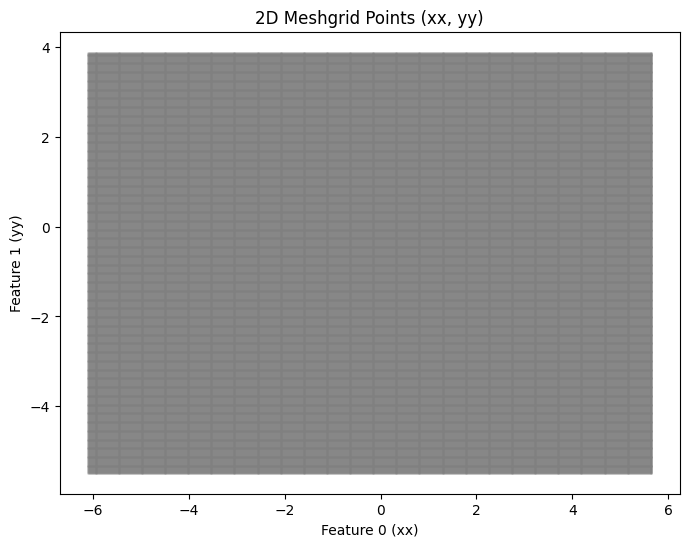

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(xx, yy, s=1, c='gray', alpha=0.3)
plt.xlabel("Feature 0 (xx)")
plt.ylabel("Feature 1 (yy)")
plt.title("2D Meshgrid Points (xx, yy)")
plt.show()

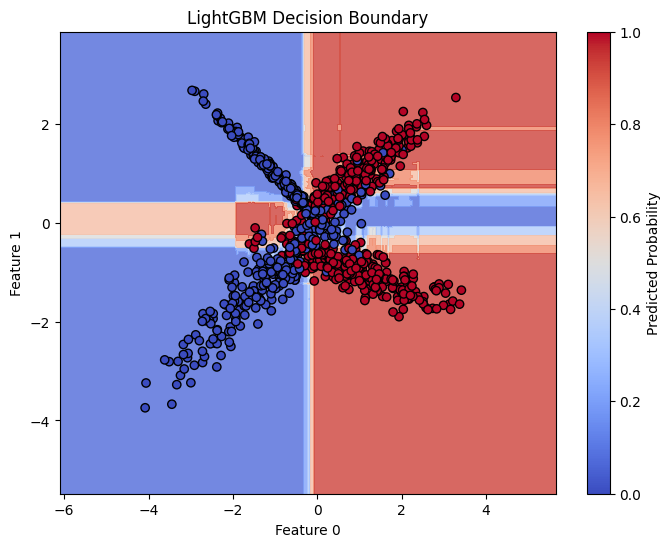

In [38]:
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='coolwarm')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("LightGBM Decision Boundary")
plt.colorbar(label="Predicted Probability")
plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
model_dt=DecisionTreeClassifier(max_depth=5,random_state=42)

In [31]:
model_dt.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [32]:
roc_auc_score(y_test, model_dt.predict_proba(X_test)[:, 1])

0.9556311603942651

In [34]:
DT=model_dt.predict_proba(np.c_[xx.ravel(),yy.ravel()])[:,1]
DT=DT.reshape(xx.shape)

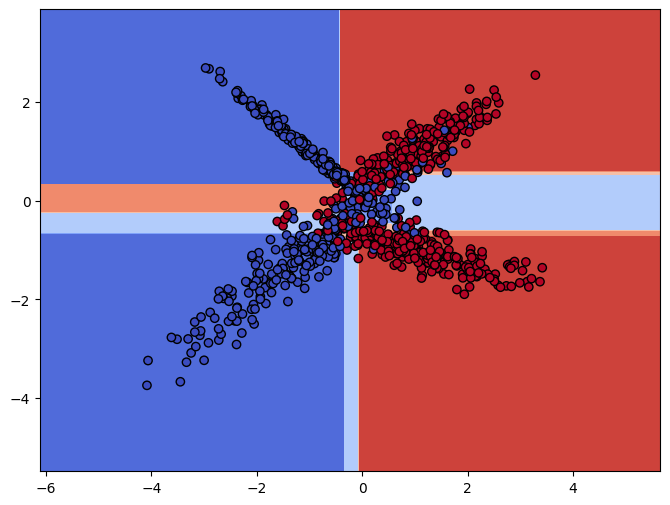

In [48]:
plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,DT,cmap='coolwarm')
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',edgecolors='k')

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix

In [52]:
cm=confusion_matrix(y_test,model.predict(X_test))

In [53]:
cm

array([[463,  41],
       [ 47, 449]])

In [54]:
dis=ConfusionMatrixDisplay(confusion_matrix=cm)

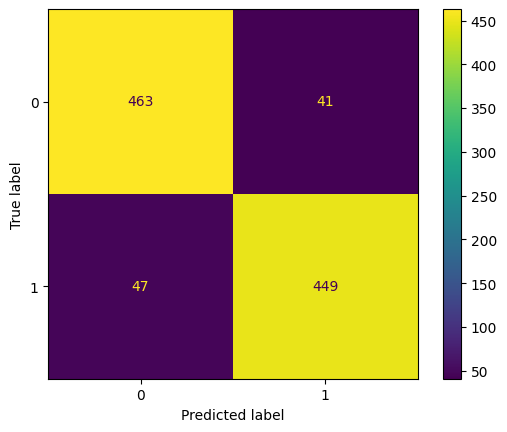

In [55]:
dis.plot()

In [56]:
from sklearn.datasets import make_moons

In [57]:
X_moon,y_moon=make_moons(n_samples=5000,noise=0.3,random_state=42)

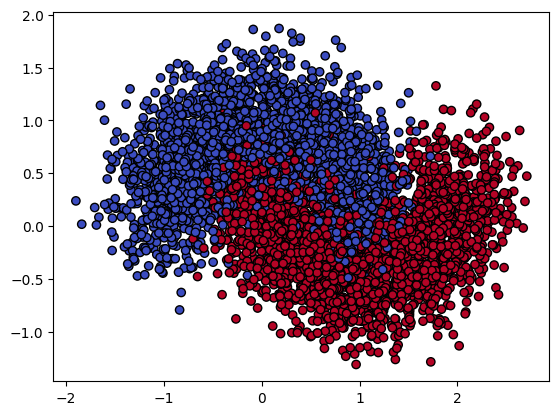

In [61]:
plt.scatter(X_moon[:,0],X_moon[:,1],c=y_moon,edgecolors='k',cmap='coolwarm')

In [62]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moon, y_moon, test_size=0.2, random_state=42
)

In [63]:
model_moon=lgb.LGBMClassifier(num_leaves=31,learning_rate=0.05,n_estimators=100,random_state=42)

In [64]:
model_moon.fit(X_train_m, y_train_m)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [65]:
roc_auc_score(y_test_m,model_moon.predict_proba(X_test_m)[:,1])

0.9700129097440504

In [66]:
from sklearn.datasets import make_circles

In [84]:
X_circle,y_circle=make_circles(n_samples=1000,noise=0.05,factor=0.5)

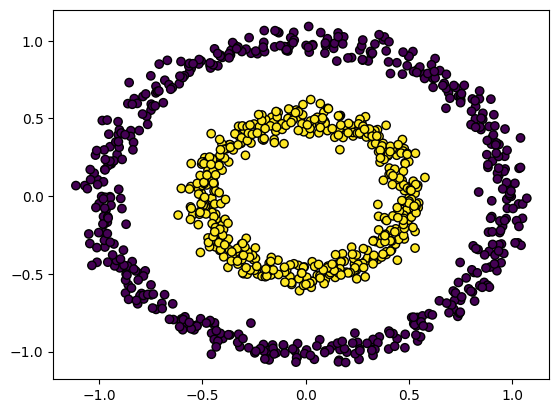

In [85]:
plt.scatter(X_circle[:,0],X_circle[:,1],edgecolors='k',c=y_circle)

In [86]:
model_circle=lgb.LGBMClassifier()

In [87]:
X_train_c,X_test_c,y_train_c,y_test_c=train_test_split(X_circle,y_circle,random_state=42,test_size=0.3)

In [88]:
model_circle.fit(X_train_c,y_train_c)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [89]:
x_min, x_max = X_circle[:, 0].min() - 0.2, X_circle[:, 0].max() + 0.2
y_min, y_max = X_circle[:, 1].min() - 0.2, X_circle[:, 1].max() + 0.2

In [91]:
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))

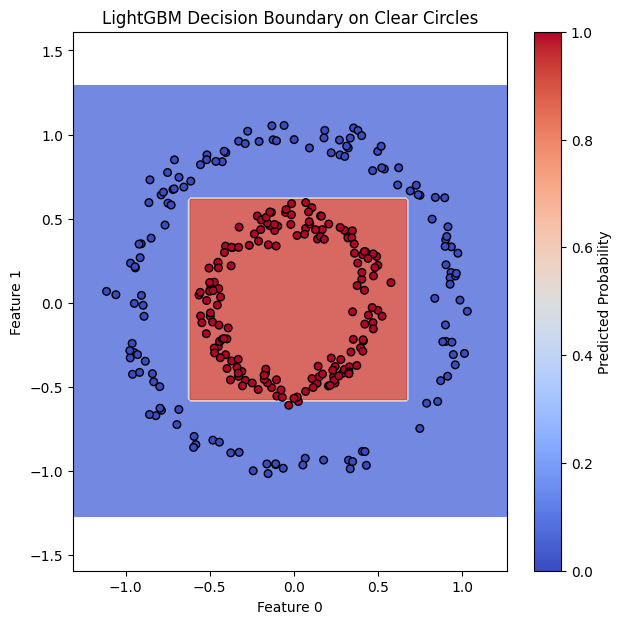

Circles Dataset ROC-AUC Score: 0.9932


In [93]:
# 1. Grid points par probabilities predict karein
Z_circle = model_circle.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_circle = Z_circle.reshape(xx.shape)

# 2. Contour Plot aur Circle Test Points
plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, Z_circle, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test_c[:, 0], X_test_c[:, 1], c=y_test_c, edgecolors='k', cmap='coolwarm', s=30)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("LightGBM Decision Boundary on Clear Circles")
plt.colorbar(label="Predicted Probability")
plt.axis('equal')
plt.show()

# 3. Test Set ROC-AUC Score
auc_circle = roc_auc_score(y_test_c, model_circle.predict_proba(X_test_c)[:, 1])
print(f"Circles Dataset ROC-AUC Score: {auc_circle:.4f}")

In [94]:
from sklearn.svm import SVC

In [95]:
model_svm=SVC(kernel='rbf',probability=True,random_state=42)

In [96]:
model_svm.fit(X_train_c, y_train_c)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [99]:
roc_auc_score(y_test_c, model_svm.predict_proba(X_test_c)[:, 1])

1.0

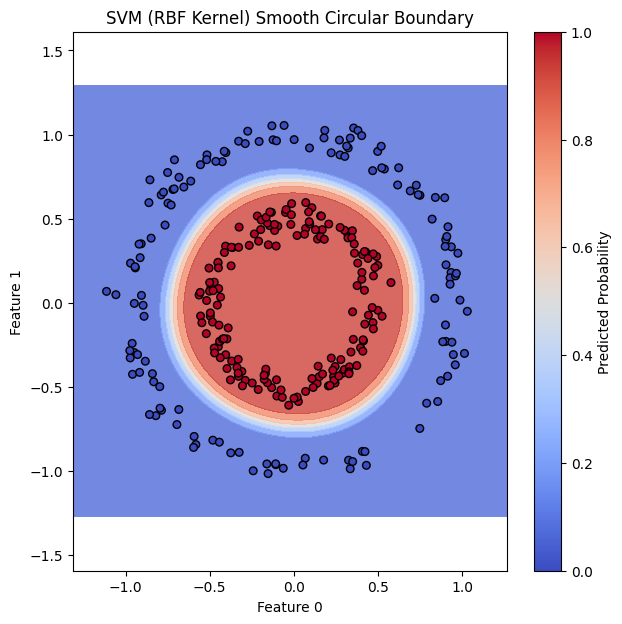

In [100]:
# Grid predictions for SVM
Z_svm = model_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_svm = Z_svm.reshape(xx.shape)

plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, Z_svm, alpha=0.8, cmap='coolwarm')
plt.scatter(X_test_c[:, 0], X_test_c[:, 1], c=y_test_c, edgecolors='k', cmap='coolwarm', s=30)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("SVM (RBF Kernel) Smooth Circular Boundary")
plt.colorbar(label="Predicted Probability")
plt.axis('equal')
plt.show()